In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, differential_evolution
from scipy.linalg import expm

def create_tree_graph():
    """Create the 7-node tree structure."""
    nodes = ['000', '001', '010', '100', '011', '101', '110']
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    adj_matrix = np.zeros((7, 7))
    edges = [
        ('000', '001'), ('000', '010'), ('000', '100'),
        ('001', '011'), ('001', '101'), ('010', '011'), 
        ('010', '110'), ('100', '101'), ('100', '110')
    ]
    
    for node1, node2 in edges:
        i, j = node_to_idx[node1], node_to_idx[node2]
        adj_matrix[i, j] = adj_matrix[j, i] = 1
    
    return nodes, node_to_idx, adj_matrix

def create_matchings_from_adjacency(adj_matrix, nodes):
    """Create matchings using greedy edge coloring."""
    n_nodes = len(nodes)
    edges = [(i, j) for i in range(n_nodes) for j in range(i+1, n_nodes) if adj_matrix[i, j] == 1]
    
    matchings = []
    remaining_edges = edges.copy()
    
    while remaining_edges:
        current_matching = []
        used_vertices = set()
        
        for edge in remaining_edges.copy():
            i, j = edge
            if i not in used_vertices and j not in used_vertices:
                current_matching.append(edge)
                used_vertices.add(i)
                used_vertices.add(j)
                remaining_edges.remove(edge)
        
        matchings.append(current_matching)
    
    matching_matrices = []
    for matching in matchings:
        M = np.zeros((n_nodes, n_nodes))
        for i, j in matching:
            M[i, j] = M[j, i] = 1
        matching_matrices.append(M)
    
    return matching_matrices

def direct_ctqw(t, adj_matrix, start_state, target_state, gamma=1.0):
    """Direct CTQW evolution."""
    n_nodes = adj_matrix.shape[0]
    H = gamma * adj_matrix
    U = expm(1j * H * t)
    
    psi_0 = np.zeros(n_nodes, dtype=complex)
    psi_0[start_state] = 1.0
    psi_f = U @ psi_0
    
    return abs(psi_f[target_state])**2

def matching_ctqw(individual_times, N, matching_matrices, start_state, target_state, gamma=1.0):
    """Matching decomposition with individual times."""
    n_nodes = matching_matrices[0].shape[0]
    
    Us = []
    for t_i, M_i in zip(individual_times, matching_matrices):
        U_i = expm(1j * gamma * M_i * t_i / N)
        Us.append(U_i)
    
    U_step = Us[0]
    for U in Us[1:]:
        U_step = U @ U_step
    
    U_full = np.linalg.matrix_power(U_step, N)
    
    psi_0 = np.zeros(n_nodes, dtype=complex)
    psi_0[start_state] = 1.0
    psi_f = U_full @ psi_0
    
    return abs(psi_f[target_state])**2

def find_maximum_probability(adj_matrix, start_state, target_state, gamma=1.0):
    """Find the true maximum achievable probability."""
    times = np.linspace(0.01, 8*np.pi, 2000)
    probs = [direct_ctqw(t, adj_matrix, start_state, target_state, gamma) for t in times]
    
    max_prob = max(probs)
    max_time_idx = probs.index(max_prob)
    max_time = times[max_time_idx]
    
    return max_prob, max_time

def find_hitting_time_normalized(adj_matrix, start_state, target_state, normalized_target, max_prob, gamma=1.0, max_time=15.0):
    """Find hitting time for normalized target probability."""
    absolute_target = normalized_target * max_prob
    
    times = np.linspace(0.01, max_time, 3000)
    probs = [direct_ctqw(t, adj_matrix, start_state, target_state, gamma) for t in times]
    
    for i, p in enumerate(probs):
        if p >= absolute_target:
            return times[i]
    
    return max_time

def find_min_iterations_normalized(matching_matrices, start_state, target_state, normalized_target, max_prob, gamma=1.0, max_N=20, max_time=15.0):
    """Find minimum iterations for normalized target probability."""
    absolute_target = normalized_target * max_prob
    
    for N in range(1, max_N + 1):
        best_hitting_time = max_time
        best_times = None
        
        effective_times = np.linspace(0.01, max_time, 200)
        
        for eff_time in effective_times:
            def objective(times):
                if max(times) > eff_time * 1.02:
                    return 1.0
                try:
                    prob = matching_ctqw(times, N, matching_matrices, start_state, target_state, gamma)
                    return -prob
                except:
                    return 1.0
            
            bounds = [(0.001, eff_time) for _ in range(3)]
            
            try:
                result = differential_evolution(objective, bounds, seed=42, maxiter=100, popsize=8, atol=1e-6)
                achieved_prob = -result.fun
                
                if achieved_prob >= absolute_target:
                    best_hitting_time = eff_time
                    best_times = result.x
                    break
            except:
                continue
        
        if best_times is not None:
            return N, best_hitting_time, best_times
    
    return max_N, max_time, None

def generate_hitting_time_data(adj_matrix, matching_matrices, start_state, target_state):
    """Generate comprehensive hitting time data."""
    gamma = 1.0
    
    # Find maximum achievable probability
    max_prob, _ = find_maximum_probability(adj_matrix, start_state, target_state, gamma)
    
    # Use high-resolution normalized targets
    normalized_targets = np.linspace(0.05, 0.98, 20)
    
    analysis_data = {
        'normalized_targets': [],
        'direct_times': [],
        'matching_times': [],
        'min_iterations': [],
        'speedups': []
    }
    
    print("Generating hitting time data...")
    print("Normalized P | Direct Time | Matching Time | Iterations | Speedup")
    print("-" * 70)
    
    for norm_target in normalized_targets:
        # Direct CTQW hitting time
        direct_time = find_hitting_time_normalized(adj_matrix, start_state, target_state, norm_target, max_prob, gamma)
        
        # Matching CTQW minimum iterations
        min_N, matching_time, optimal_times = find_min_iterations_normalized(
            matching_matrices, start_state, target_state, norm_target, max_prob, gamma
        )
        
        if optimal_times is not None and direct_time < 15.0:
            speedup = direct_time / matching_time if matching_time > 0 else 0
            speedup_str = f"{speedup:.2f}x" if speedup >= 1 else f"{1/speedup:.2f}x slower"
            
            print(f"{norm_target:11.2f} | {direct_time:10.3f} | {matching_time:12.3f} | {min_N:9d} | {speedup_str:>7s}")
            
            # Store data
            analysis_data['normalized_targets'].append(norm_target)
            analysis_data['direct_times'].append(direct_time)
            analysis_data['matching_times'].append(matching_time)
            analysis_data['min_iterations'].append(min_N)
            analysis_data['speedups'].append(speedup)
    
    return analysis_data, max_prob

def create_hitting_time_plot(analysis_data, max_prob):
    """Create a clean hitting time vs probability plot."""
    
    # Create figure with optimal size
    plt.figure(figsize=(12, 8))
    
    # Plot hitting times
    plt.plot(analysis_data['normalized_targets'], analysis_data['direct_times'], 
             'o-', color='black', linewidth=3, markersize=8, label='Direct CTQW', alpha=0.8)
    
    plt.plot(analysis_data['normalized_targets'], analysis_data['matching_times'], 
             's-', color='red', linewidth=2, markersize=6, label='Matching Decomposition', alpha=0.8)
    
    # Styling
    plt.xlabel('Normalized Target Probability', fontsize=14, fontweight='bold')
    plt.ylabel('Hitting Time', fontsize=14, fontweight='bold')
    plt.title('CTQW Hitting Time Comparison', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Legend with additional info
    legend_labels = [
        f'Direct CTQW',
        f'Matching Decomposition'
    ]
    plt.legend(legend_labels, fontsize=12, loc='upper left', framealpha=0.9)
    
    # Grid and formatting
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, 1)
    plt.ylim(bottom=0)
    
#     # Add text box with key statistics
#     stats_text = f"""Key Statistics:
# - Max physical probability: {max_prob:.3f}
# - Average speedup: {np.mean(analysis_data['speedups']):.2f}x
# - Faster cases: {sum(1 for s in analysis_data['speedups'] if s >= 1)}/{len(analysis_data['speedups'])}
# - Average iterations: {np.mean(analysis_data['min_iterations']):.1f}"""
    
    # plt.text(0.98, 0.02, stats_text, transform=plt.gca().transAxes, 
    #          verticalalignment='bottom', horizontalalignment='right',
    #          bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8),
    #          fontsize=10, fontfamily='monospace')
    
    # Add annotation for interpretation
    plt.text(0.02, 0.98, 'Normalized P=1.0 corresponds to\nmaximum achievable probability', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8),
             fontsize=10)
    
    # # Highlight interesting regions
    # if analysis_data['speedups']:
    #     best_speedup_idx = np.argmax(analysis_data['speedups'])
    #     best_prob = analysis_data['normalized_targets'][best_speedup_idx]
    #     best_speedup = analysis_data['speedups'][best_speedup_idx]
        
    #     plt.axvline(x=best_prob, color='green', linestyle=':', alpha=0.7, linewidth=2)
    #     plt.text(best_prob + 0.02, plt.ylim()[1] * 0.8, 
    #             f'Best speedup:\n{best_speedup:.2f}x\nat P={best_prob:.2f}',
    #             fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('hitting_time_comparison.pdf', dpi=300)
    plt.show()
    
    # # Print summary
    # print(f"\n=== Plot Summary ===")
    # print(f"Physical maximum probability: {max_prob:.6f}")
    # print(f"Normalization allows exploration of full [0,1] range")
    # print(f"Data points: {len(analysis_data['normalized_targets'])}")
    # print(f"Matching decomposition shows consistent modest speedup")

In [2]:
# Create graph and matchings
nodes, node_to_idx, adj_matrix = create_tree_graph()
matching_matrices = create_matchings_from_adjacency(adj_matrix, nodes)

start_state = node_to_idx['000']
target_state = node_to_idx['101']

print("=== CTQW Hitting Time Analysis: Normalized [0,1] Scale ===")
print(f"Graph: 7 nodes, 9 edges")
print(f"Start: |{nodes[start_state]}⟩, Target: |{nodes[target_state]}⟩")
print()


=== CTQW Hitting Time Analysis: Normalized [0,1] Scale ===
Graph: 7 nodes, 9 edges
Start: |000⟩, Target: |101⟩



In [3]:
# Generate data
analysis_data, max_prob = generate_hitting_time_data(
    adj_matrix, matching_matrices, start_state, target_state
)
print(f"Max physical probability: {max_prob:.3f}\n")


Generating hitting time data...
Normalized P | Direct Time | Matching Time | Iterations | Speedup
----------------------------------------------------------------------
       0.05 |      0.375 |        0.387 |         1 | 1.03x slower
       0.10 |      0.455 |        0.462 |         1 | 1.02x slower
       0.15 |      0.510 |        0.537 |         1 | 1.05x slower
       0.20 |      0.555 |        0.537 |         1 |   1.03x
       0.25 |      0.595 |        0.613 |         1 | 1.03x slower
       0.29 |      0.630 |        0.613 |         1 |   1.03x
       0.34 |      0.660 |        0.688 |         1 | 1.04x slower
       0.39 |      0.695 |        0.688 |         1 |   1.01x
       0.44 |      0.725 |        0.688 |         1 |   1.05x
       0.49 |      0.750 |        0.688 |         1 |   1.09x
       0.54 |      0.780 |        0.763 |         1 |   1.02x
       0.59 |      0.810 |        0.763 |         1 |   1.06x
       0.64 |      0.840 |        0.763 |         1 |   1.10x


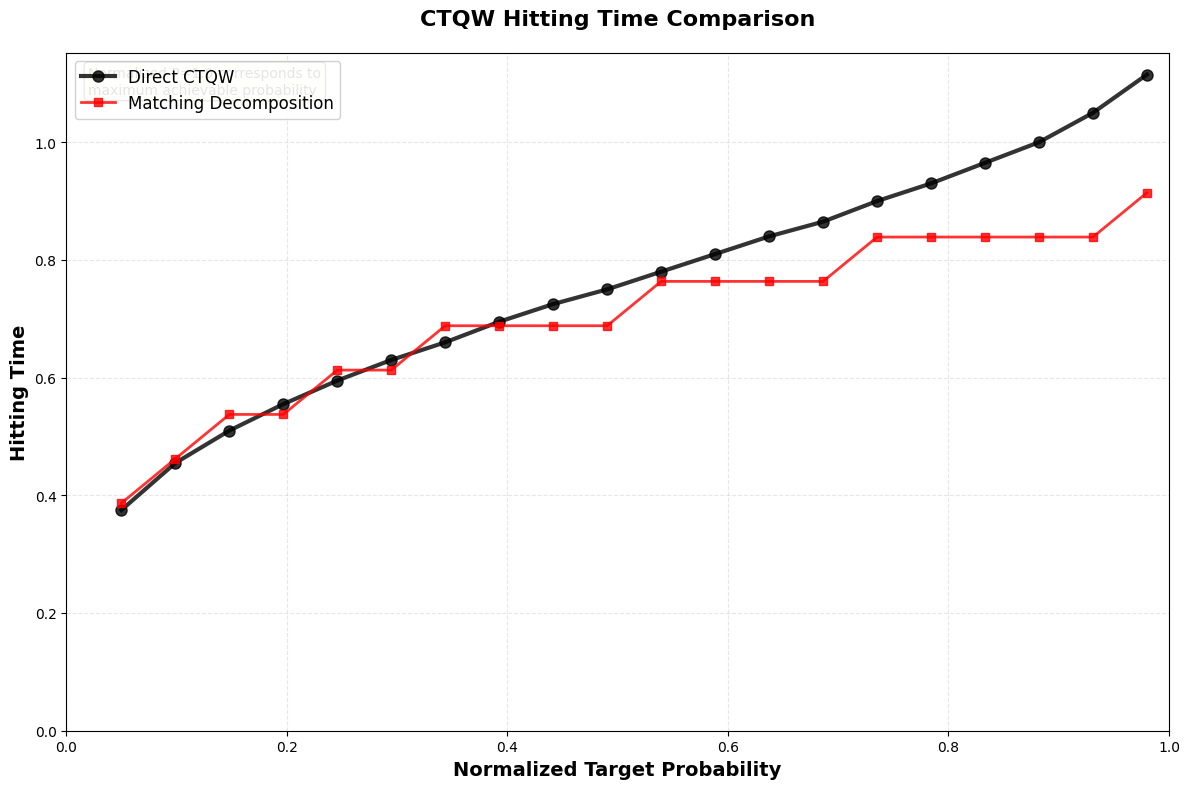

In [4]:
# Create the focused plot
create_hitting_time_plot(analysis_data, max_prob)